In [1]:
from matplotlib import testing
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import cupy
import os

kaggle = True if os.environ.get('KAGGLE_URL_BASE','') else False
balanced = True
testing_mode = True

if kaggle:
    training_data = '/kaggle/input/competitions/playground-series-s6e4/train.csv'
else:
    training_data = 'data/train.csv'

df_tv = pd.read_csv(training_data)
df_x = df_tv.iloc[:,1:-1]

df_dummy = pd.get_dummies(df_x, dtype=int, drop_first=False)
newcolumns = df_dummy.columns.values.tolist() + ['Irrigation_Need']
continous_variables = df_dummy.select_dtypes(['float64']).columns
index = [df_dummy.columns.get_loc(col) for col in continous_variables]

x = df_dummy.iloc[:,:].values
y = df_tv.iloc[:,-1].values

class_le = LabelEncoder()
y = class_le.fit_transform(y)

if testing_mode:
    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = \
        train_test_split(x, y, 
                        test_size=0.20,
                        stratify=y,
                        random_state=1)
else:
    X_train, y_train = x, y

sc = StandardScaler().fit(X_train[:, index])
X_train[:, index] = sc.transform(X_train[:, index])

if testing_mode:
    X_test[:, index] = sc.transform(X_test[:, index])


if balanced:
    majority_class = np.argmax(np.bincount(y_train))
    minority_class = np.argmin(np.bincount(y_train))
    middle_class = list(set(np.unique(y_train)) - set([majority_class, minority_class]))[0]
    X_train_majority = X_train[y_train == majority_class]
    y_train_majority = y_train[y_train == majority_class]
    
    X_train_minority = X_train[y_train == minority_class]
    y_train_minority = y_train[y_train == minority_class]
    
    X_train_middle = X_train[y_train == middle_class]
    y_train_middle = y_train[y_train == middle_class]
    
    
    X_train_minority_upsampled, y_train_minority_upsampled = resample(X_train_minority, y_train_minority,
                                                                      replace=True,
                                                                      n_samples=X_train_middle.shape[0],
                                                                      random_state=1)
    X_train_majority_downsampled, y_train_majority_downsampled = resample(X_train_majority, y_train_majority,
                                                                      replace=False,
                                                                      n_samples=X_train_middle.shape[0],
                                                                      random_state=1)
    X_train_balanced = np.vstack((X_train_majority_downsampled, X_train_middle, X_train_minority_upsampled))
    y_train_balanced = np.hstack((y_train_majority_downsampled, y_train_middle, y_train_minority_upsampled))

    perm = np.random.permutation(len(X_train_balanced))

    X_train = X_train_balanced[perm]
    y_train = y_train_balanced[perm]

    train_features = np.hstack((X_train, y_train.reshape(-1, 1)))

    df_train = pd.DataFrame(train_features, columns=newcolumns)



In [5]:
X_train[0,:]

array([ 0.74591389,  0.06992044, -1.37475064, -1.34897882,  1.73190103,
       -1.22314539, -1.05200506,  0.88795614,  0.5700554 , -1.41116883,
       -1.46577766,  0.        ,  1.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
        0.        ,  1.        ,  0.        ,  0.        ,  1.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
        0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  0.        ,  0.        ])

In [5]:





# df_tv = pd.read_csv(training_data)
# counts = df_tv['Irrigation_Need'].value_counts()
# continous_variables = df_tv.select_dtypes(['float64']).columns

# #balanced data set
# df_tv_majority = df_tv[df_tv['Irrigation_Need'] == counts.keys()[0]]
# df_tv_mid = df_tv[df_tv['Irrigation_Need'] == counts.keys()[1]]
# df_tv_minority = df_tv[df_tv['Irrigation_Need'] == counts.keys()[2]]

# # Downsample majority class
# majority_downsampled = resample(df_tv_majority, 
#                               replace=False,  # Sample without replacement
#                               n_samples=len(df_tv_mid),  # Equalize class sizes
#                               random_state=42)
# # Oversample minority class
# minority_upsampled = resample(df_tv_minority, 
#                               replace=True,  # Sample with replacement
#                               n_samples=len(df_tv_mid),  # Equalize class sizes
#                               random_state=42)
# # # Oversample mid class
# # mid_upsampled = resample(df_tv_mid, 
# #                          replace=True,  # Sample with replacement
# #                          n_samples=len(df_tv_majority),  # Equalize class sizes
# #                          random_state=42)
# #df_balanced = pd.concat([df_tv_majority, mid_upsampled, minority_upsampled])
# df_balanced = pd.concat([df_tv_mid, majority_downsampled, minority_upsampled])    
# df_tv = df_balanced if balanced else df_tv



# class_le = LabelEncoder()
# y = class_le.fit_transform(df_balanced['Irrigation_Need'].values)

# df_dummy = pd.get_dummies(df_balanced.iloc[:,1:-1], dtype=int, drop_first=True)

# sc = StandardScaler().fit(df_dummy[continous_variables])
# df_dummy[continous_variables] = sc.transform(df_dummy[continous_variables])
# x = df_dummy.to_numpy()

# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = \
#     train_test_split(x, y, 
#                      test_size=0.20,
#                      stratify=y,
#                      random_state=1)




In [7]:
import joblib
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight="balanced", solver="lbfgs", C=0.1)
model.fit(X_train, y_train)
predictions = model.predict_proba(X_test)
roc_auc_score(y_test, predictions, multi_class="ovo")

np.float64(0.958769826877497)

In [11]:
predictions = model.predict_proba(X_test)

print("Creating classification evaluation report")
report_dict = classification_report(y_test, predictions.argmax(axis=1), output_dict=True)
report_dict["accuracy"] = accuracy_score(y_test, predictions.argmax(axis=1))
report_dict["roc_auc"] = roc_auc_score(y_test, predictions, multi_class="ovo")

print("Classification report:\n{}".format(report_dict))

Creating classification evaluation report
Classification report:
{'0': {'precision': 0.3837136929460581, 'recall': 0.8802950975725845, 'f1-score': 0.5344603381014305, 'support': 4202.0}, '1': {'precision': 0.9342369190211474, 'recall': 0.8813646378222024, 'f1-score': 0.9070309294125012, 'support': 73983.0}, '2': {'precision': 0.8013057297483034, 'recall': 0.7803408972079892, 'f1-score': 0.7906843683446529, 'support': 47815.0}, 'accuracy': 0.8429920634920635, 'macro avg': {'precision': 0.7064187805718363, 'recall': 0.8473335442009254, 'f1-score': 0.7440585452861948, 'support': 126000.0}, 'weighted avg': {'precision': 0.8654321300445715, 'recall': 0.8429920634920635, 'f1-score': 0.8504543227287847, 'support': 126000.0}, 'roc_auc': np.float64(0.958769826877497)}


In [4]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
def plot_confusion_matrix(y_pred, y_test):

    labels = class_le.inverse_transform(np.unique(y_pred))
    confmat = confusion_matrix(class_le.inverse_transform(y_test), 
                            class_le.inverse_transform(y_pred), 
                            sample_weight=None, normalize=None)
    fig, ax = plt.subplots(figsize=(2.5, 2.5))
    ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
    for i in range(confmat.shape[0]):
        for j in range(confmat.shape[1]):
            ax.text(x=j, y=i, s=confmat[i, j],
                va='center', ha='center')
            ax.xaxis.set_ticks_position('bottom')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()


In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
# mxgb_gs = GridSearchCV(xgb.XGBClassifier(random_state=1, tree_method='hist', device='cuda', n_jobs=-1, objective='multi:softmax', num_class=3), 
#                          param_grid={'n_estimators': [100, 500, 1000], 'learning_rate': [0.01, 0.1], 
#                                      'max_depth': [3, 4, 5, 10], 'lambda': [1, 10, 100]}, 
#                          cv=5, scoring='balanced_accuracy')

# mxgb_gs.fit(cupy.array(X_train), y_train)
# mxgb_gs.score(X_test, y_test)

# mxgb_gs = HalvingGridSearchCV(xgb.XGBClassifier(random_state=1, tree_method='hist', 
#                                                 device='cuda', n_jobs=-1, 
#                                                 objective='multi:softmax', num_class=3, eval_metric='merror'), 
#                          param_grid={'n_estimators': [2000], 'learning_rate': [0.01, 0.1], 
#                                      'max_depth': [3, 4, 5, 10], 'lambda': [1, 10, 100]}, 
#                          cv=5, scoring='balanced_accuracy')

# mxgb_gs.fit(cupy.array(X_train), y_train)
# mxgb_gs.score(cupy.array(X_test), y_test)

0.9658101899377165

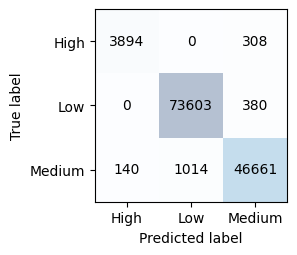

{'lambda': 1, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 2000}


In [ ]:
# plot_confusion_matrix(mxgb_gs.predict(cupy.array(X_test)), y_test)
# print(mxgb_gs.best_params_)

mxgb_gs.best_params_ = {'lambda': 1, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 2000}
scored: .965

In [2]:


mxgb = xgb.XGBClassifier(random_state=1, tree_method='hist', device='cuda', n_jobs=-1,
                       n_estimators=2000, learning_rate=0.1, max_depth=10, reg_lambda=1, 
                       objective='multi:softmax', num_class=3, eval_metric='merror')
mxgb.fit(cupy.array(X_train), y_train)
mxgb.score(X_test, y_test)



/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [17:13:44] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


0.9853809523809524

In [ ]:
import json
import numpy as np
import pandas as pd
import s3fs
from pathlib import Path
from sagemaker import MetricsSource, ModelMetrics
from sagemaker.serve.builder.model_builder import ModelBuilder
from sagemaker.serve.builder.schema_builder import SchemaBuilder
from sagemaker.serve.spec.inference_spec import InferenceSpec
from sagemaker.utils import unique_name_from_base
from xgboost import XGBClassifier
from sagemaker.serve import ModelServer
import boto3
from sagemaker import Session
from sagemaker import get_execution_role

model = mxgb

# Set path to config file
os.environ["SAGEMAKER_USER_CONFIG_OVERRIDE"] = os.getcwd()

session = boto3.Session(region_name='us-east-1', profile_name='sagemaker')
sagemaker_session = Session(boto_session=session)
s3 = session.client('s3')
#sm = Session()
#s3 = sm.boto_session.client('s3')
region = sagemaker_session.boto_region_name
#role_arn = os.environ.get('SAGEMAKER_EXECUTION_ROLE_ARN')
role = get_execution_role(sagemaker_session=sagemaker_session)
print(f"Using role: {role}")

schema_builder = SchemaBuilder(
    sample_input=X_train,
    sample_output=model.predict(X_test),
)

model_path = Path("/tmp/model/")
model_path.mkdir(parents=True, exist_ok=True)
model.save_model(model_path / "xgboost-model")

bucket_name = 'jrm-kaggle'
prefix = 'playgrounds6ep4/'
object_name = 'train.csv'
input_path = f"s3://{bucket_name}/{prefix}{object_name}"

class XGBoostSpec(InferenceSpec):
    def load(self, model_dir: str):
        print(model_dir)
        model = XGBClassifier()
        model.load_model(model_dir + "/xgboost-model")
        return model

    def invoke(self, input_object: object, model: object):
        prediction_probabilities = model.predict_proba(input_object)
        predictions = np.argmax(prediction_probabilities, axis=1)
        return predictions

from sagemaker import image_uris
sklearn_image_uri = image_uris.retrieve(
    framework="sklearn",
    region='us-east-1',
    version="1.4-2",  # Use appropriate version
    py_version="py3",
    instance_type="ml.m5.large"
)

print(f"Using image URI: {sklearn_image_uri}")
# Build the trained model and register it
model_builder = ModelBuilder(
    model_path=str(model_path),
    inference_spec=XGBoostSpec(),
    schema_builder=schema_builder,
    #model=mxgb,
    #image_uri="public.ecr.aws/sagemaker/sagemaker-distribution:latest-gpu",
    image_uri=sklearn_image_uri,
    #model_server=ModelServer.TORCHSERVE,
    sagemaker_session=sagemaker_session,
    role_arn='arn:aws:iam::801638386573:role/service-role/AmazonSageMaker-ExecutionRole-20260227T135383',
    s3_model_data_url=f"s3://{bucket_name}/standalone-test/model-artifacts",
    dependencies={"auto":True}
    #dependencies={"requirements":"requirements.txt"}
)
model_builder.build()
# model_package = model_builder.build().register(
#     model_package_group_name='standalone-test',
# )

INFO:botocore.credentials:Found credentials in environment variables.


Using role: arn:aws:iam::801638386573:role/service-role/AmazonSageMaker-ExecutionRole-20260227T135383


/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/xgboost/sklearn.py:1116: UserWarning: [18:00:58] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


Using image URI: 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-scikit-learn:1.4-2-cpu-py3


ModelBuilder: INFO:     ModelBuilder will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features. To opt out of telemetry, please disable via TelemetryOptOut in intelligent defaults. See https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk for more info.


[04/09/26 18:01:00] INFO     Either inference spec or model is provided. ModelBuilder is not   ]8;id=834496;file:///home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sagemaker/serve/builder/model_builder.py\model_builder.py]8;;\:]8;id=406576;file:///home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sagemaker/serve/builder/model_builder.py#845\845]8;;\
                             handling MLflow model input                                                           

INFO:sagemaker_core.main.utils:Either inference spec or model is provided. ModelBuilder is not handling MLflow model input


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:71                                                                                   │
│                                                                                                  │
│   68 │   dependencies={"auto":True}                                                              │
│   69 │   #dependencies={"requirements":"requirements.txt"}                                       │
│   70 )                                                                                           │
│ ❱ 71 model_builder.build()                                                                       │
│   72 # model_package = model_builder.build().register(                                           │
│   73 #     model_package_group_name='standalone-test',                                           │
│   74 # )                                                                                         │
│                                                                                                  │
│ /home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sagemaker/serve/builder/model_bu │
│ ilder.py:1022 in build                                                                           │
│                                                                                                  │
│   1019 │   │   │   self.inference_spec, (CustomOrchestrator, AsyncCustomOrchestrator)            │
│   1020 │   │   ):                                                                                │
│   1021 │   │   │   self.serve_settings = self._get_serve_setting()                               │
│ ❱ 1022 │   │   │   return self._build_single_modelbuilder(                                       │
│   1023 │   │   │   │   mode=mode,                                                                │
│   1024 │   │   │   │   role_arn=self.role_arn,                                                   │
│   1025 │   │   │   │   sagemaker_session=sagemaker_session,                                      │
│                                                                                                  │
│ /home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sagemaker/serve/utils/telemetry_ │
│ logger.py:117 in wrapper                                                                         │
│                                                                                                  │
│   114 │   │   │   │   failure_reason = str(e)                                                    │
│   115 │   │   │   │   failure_type = e.__class__.__name__                                        │
│   116 │   │   │   except Exception as e:  # pylint: disable=W0703                                │
│ ❱ 117 │   │   │   │   raise e                                                                    │
│   118 │   │   │                                                                                  │
│   119 │   │   │   stop_timer = perf_counter()                                                    │
│   120 │   │   │   elapsed = stop_timer - start_timer                                             │
│                                                                                                  │
│ /home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sagemaker/serve/utils/telemetry_ │
│ logger.py:105 in wrapper                                                                         │
│                                                                                                  │
│   102 │   │   │                                                                                  │
│   103 │   │   │   start_timer = perf_counter()                                                   │
│   104 │   │   │   try:                                                                           │
│ ❱ 105 │   │   │   │   response = func(self, *args, **kwargs

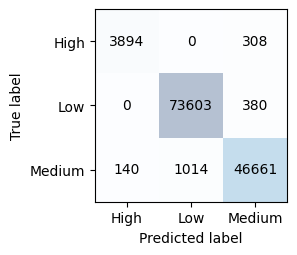

In [6]:
plot_confusion_matrix(mxgb.predict(X_test), y_test)

In [7]:
from lightgbm import LGBMClassifier
# device='cuda' is only supported in lightgbm built with: 
# pip install lightgbm --install-option=cmake.define.USE_CUDA=ON
lgbm = LGBMClassifier(class_weight="balanced", n_estimators=500, 
                      learning_rate=0.1, max_depth=10, reg_lambda=1,
                      boosting_type='gbdt')
lgbm.fit(X_train, y_train)
lgbm.score(X_test, y_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028864 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2738
[LightGBM] [Info] Number of data points in the train set: 573777, number of used features: 43
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9847063492063493

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


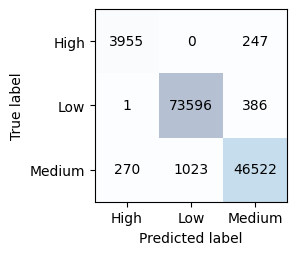

In [8]:
plot_confusion_matrix(lgbm.predict(X_test), y_test)

In [9]:
from catboost import CatBoostClassifier, Pool

test_data = catboost_pool = Pool(X_test,
                                 y_test)

#weights = dict(zip(class_le.transform(class_le.classes_), [.2, .2, .6]))
params = {'iterations': 2000,
          'depth': 10,
          'learning_rate': .1,
          'loss_function': 'MultiClass',
          'verbose': True,
          'task_type': 'GPU',
          'reg_lambda': 1,}
          #'class_weights': weights}
#cb = CatBoostClassifier(**params)
                        
#cb.fit(X_train, y_train)
#cb.score(X_test, y_test)


from sklearn.base import clone

class CustomCatBoostClassifier(CatBoostClassifier):
    def __sklearn_clone__(self):
        return CustomCatBoostClassifier(**self.get_params())
    
cb = CustomCatBoostClassifier(**params)
                        
cb.fit(X_train, y_train)
cb.score(X_test, y_test)

0:	learn: 0.9253726	total: 202ms	remaining: 6m 43s
1:	learn: 0.7963523	total: 255ms	remaining: 4m 15s
2:	learn: 0.6954337	total: 310ms	remaining: 3m 26s
3:	learn: 0.6140590	total: 372ms	remaining: 3m 5s
4:	learn: 0.5468841	total: 425ms	remaining: 2m 49s
5:	learn: 0.4906718	total: 472ms	remaining: 2m 36s
6:	learn: 0.4430370	total: 520ms	remaining: 2m 27s
7:	learn: 0.4022990	total: 566ms	remaining: 2m 21s
8:	learn: 0.3670664	total: 615ms	remaining: 2m 16s
9:	learn: 0.3365506	total: 666ms	remaining: 2m 12s
10:	learn: 0.3098907	total: 728ms	remaining: 2m 11s
11:	learn: 0.2864606	total: 784ms	remaining: 2m 9s
12:	learn: 0.2660333	total: 836ms	remaining: 2m 7s
13:	learn: 0.2478446	total: 883ms	remaining: 2m 5s
14:	learn: 0.2318879	total: 942ms	remaining: 2m 4s
15:	learn: 0.2177388	total: 1s	remaining: 2m 4s
16:	learn: 0.2050436	total: 1.06s	remaining: 2m 3s
17:	learn: 0.1938451	total: 1.13s	remaining: 2m 4s
18:	learn: 0.1838706	total: 1.18s	remaining: 2m 3s
19:	learn: 0.1748150	total: 1.23s	

np.float64(0.9836984126984127)

In [12]:
dict(zip(class_le.classes_, [.2, .2, .6]))

{'High': 0.2, 'Low': 0.2, 'Medium': 0.6}

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


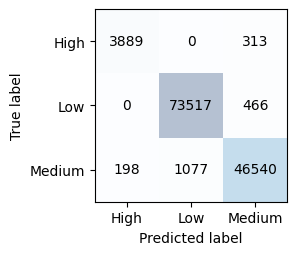

In [10]:
plot_confusion_matrix(cb.predict(X_test), y_test)

In [16]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(estimators=[('xgb', mxgb), ('lgbm', lgbm), ('cb', cb)], voting='soft')
voting_clf.fit(X_train, y_train)
#voting_clf.score(X_test, y_test)



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2736
[LightGBM] [Info] Number of data points in the train set: 717222, number of used features: 43
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
0:	learn: 0.9250831	total: 121ms	remaining: 4m 1s
1:	learn: 0.7958512	total: 188ms	remaining: 3m 7s
2:	learn: 0.6947189	total: 253ms	remaining: 2m 48s
3:	learn: 0.6131168	total: 314ms	remaining: 2m 36s
4:	learn: 0.5458056	total: 379ms	remaining: 2m 31s
5:	learn: 0.4893990	total: 434ms	remaining: 2m 24s
6:	learn: 0.4416482	total: 490ms	remaining: 2m 19s
7:	learn: 0.4008205	total: 555ms	remaining: 2m 18s
8:	learn: 0.3655666	total: 614ms	remaining: 2m 15s
9:	learn: 0.3349124	total: 

,estimators,"[('xgb', ...), ('lgbm', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None


In [1]:
plot_confusion_matrix(voting_clf.predict(X_test), y_test)

NameError: name 'plot_confusion_matrix' is not defined

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier

base_models = [('xgb', mxgb), ('lgbm', lgbm), ('cb', cb)]
meta_model = LogisticRegression(max_iter=1000, multi_class="auto", solver="lbfgs")
#meta_model = DecisionTreeClassifier(max_depth=5, random_state=1)
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=2)
stacking_clf.fit(X_train, y_train)
stacking_clf.score(X_test, y_test)
#stacking_clf.fit(x, y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041858 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2738
[LightGBM] [Info] Number of data points in the train set: 573777, number of used features: 43
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
0:	learn: 0.9253497	total: 146ms	remaining: 4m 52s
1:	learn: 0.7962910	total: 216ms	remaining: 3m 35s
2:	learn: 0.6952847	total: 300ms	remaining: 3m 19s
3:	learn: 0.6138016	total: 373ms	remaining: 3m 6s
4:	learn: 0.5465770	total: 441ms	remaining: 2m 55s
5:	learn: 0.4902933	total: 492ms	remaining: 2m 43s
6:	learn: 0.4426242	total: 544ms	remaining: 2m 34s
7:	learn: 0.4017619	total: 596ms	remaining: 2m 28s
8:	learn: 0.3666019	total: 662ms	remaining: 2m 26s
9:	learn: 0.3360806	total: 728ms	remaining: 2m 24s
10:	learn: 0.3094646	total: 793ms	remai

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004416 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2737
[LightGBM] [Info] Number of data points in the train set: 286889, number of used features: 43
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0:	learn: 0.9251862	total: 60.4ms	remaining: 2m
1:	learn: 0.7960010	total: 113ms	remaining: 1m 53s
2:	learn: 0.6949342	total: 170ms	remaining: 1m 53s
3:	learn: 0.6133751	total: 224ms	remaining: 1m 51s
4:	learn: 0.5461345	total: 271ms	remaining: 1m 48s
5:	learn: 0.4898743	total: 323ms	remaining: 1m 47s
6:	learn: 0.4420716	total: 370ms	remaining: 1m 45s
7:	learn: 0.4012393	total: 416ms	remaining: 1m 43s
8:	learn: 0.3659977	total: 461ms	remaining: 1m 42s
9:	learn: 0.3353943	total: 513ms	remaining: 1m 42s
10:	learn: 0.3088063	total: 573ms	remaining: 1m 43s
11:	learn: 0.2853482	total: 630ms	remaining: 1m 44s
12:	learn: 0.2647621	total: 689ms	remaining: 1m 45s
13:	learn: 0.2466015	total: 745ms	remaining: 1m 45s
14:	learn: 0.2303750	total: 791ms	remaining: 1m 44s
15:	learn: 0.2161041	total: 840ms	remaining: 1m 44s
16:	learn: 0.2034517	total: 891ms	remaining: 1m 43s
17:	learn: 0.1922159	total: 951ms	remaining: 1m 44s
18:	learn: 0.1822160	total: 1.01s	remaining: 1m 44s
19:	learn: 0.1731807	tota

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.984920634920635

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


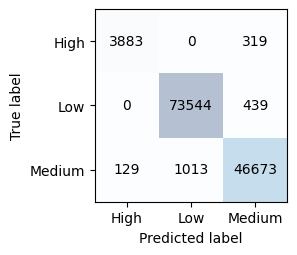

In [33]:
plot_confusion_matrix(stacking_clf.predict(X_test), y_test)

In [17]:
if kaggle:
    testing_data = '/kaggle/input/competitions/playground-series-s6e4/test.csv'
else:
    testing_data = 'data/test.csv'

df_test = pd.read_csv(testing_data)

ids = df_test['id'].values

df_test_dummy = pd.get_dummies(df_test.iloc[:,1:], drop_first=False, dtype=int)
df_test_dummy[continous_variables] = sc.transform(df_test_dummy[continous_variables])
x_test = df_test_dummy.to_numpy()
#df_test_dummy.head()
df_test_dummy[continous_variables].values

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


array([[-0.13278775, -0.67866121, -0.90992681, ..., -1.29632738,
         1.43956401, -0.43327052],
       [-0.66395094, -1.67456589,  0.7029436 , ...,  0.96751046,
        -0.33136681, -0.17193309],
       [-0.28454866, -0.65667925,  0.10153429, ..., -1.36135999,
        -1.04495473, -1.23567862],
       ...,
       [ 1.46070181, -1.60495637,  1.74174149, ..., -0.06949601,
        -1.09948138, -0.82629865],
       [ 0.69105719, -1.65624759,  1.08565861, ..., -1.56700364,
        -0.42856649, -1.70521001],
       [ 0.13821388, -0.75376622,  1.33168969, ..., -0.0782842 ,
        -0.83158957,  1.33973604]], shape=(270000, 11))

In [ ]:

if kaggle:
    out_dir = '/kaggle/working/'
else:
    out_dir = 'data/'

df_submission_stack = pd.DataFrame({'id': ids, 'Irrigation_Need': class_le.inverse_transform(voting_clf.predict(x_test))})
df_submission_stack.to_csv(os.path.join(out_dir, 'submission-votingclf_full_v1.csv'), index=False)

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


: 